# First Name: Jack
# Last Name: Kelly

# Import Libraries  

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import Data

In [84]:
bottledata = pd.read_csv('Bottle.csv', low_memory = False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# Initial Data management  - common to all tasks

In [85]:
bottledata['ChlorA'] = pd.to_numeric(bottledata['ChlorA'], errors = 'coerce') #ensure measurement is numeric

# Task 1: Histogram

0        33.500000
1        33.500000
2        33.500000
3        33.500000
4        33.500000
            ...   
895366   26.500000
895367   27.000000
895368   27.000000
895369   27.000000
895370   27.000000
Name: Salnty, Length: 895371, dtype: float64


895371

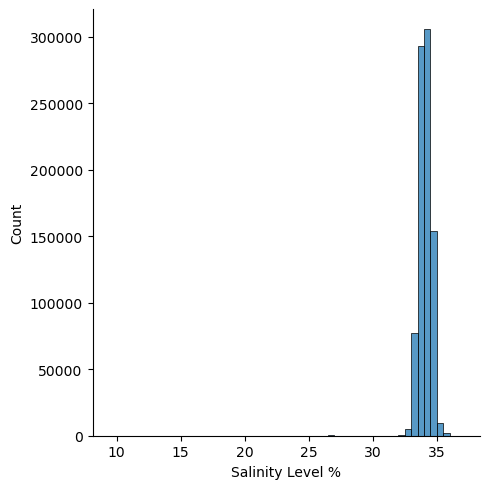

In [139]:
histogram = bottledata.copy()

#grab salinity
histogram = histogram[['Salnty']]

#round every value to the nearest 0.5%
histogram['Salnty'] = histogram['Salnty'].mul(2).round().div(2)

#print histogram
%matplotlib inline

sns.displot(histogram['Salnty'].dropna(), kde = False, binwidth = 0.5);

plt.xlabel('Salinity Level %')
plt.ylabel('Count')

print(histogram['Salnty'])
len(histogram)

# Task 2: Boxplot

,Chlqua,ChlorA
472997,Data Okay,0.640000
472998,Data Okay,0.660000
473027,Data Okay,2.730000
473028,Data Okay,3.340000
473030,Data Okay,1.380000


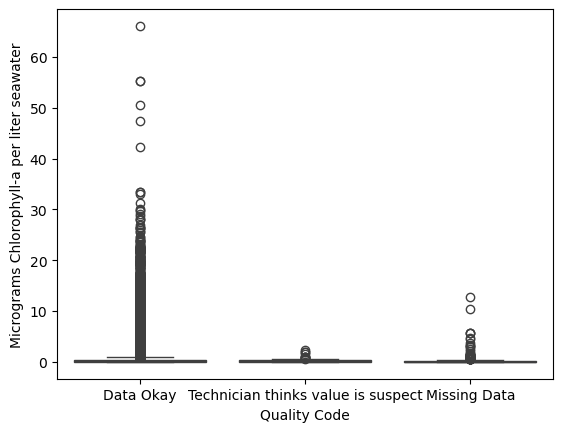

In [108]:
boxplot = bottledata.copy()

#make record indicator be read
recode = {None: 'Data Okay', 4: "Value zeroed due to value below detection limit", 6: "Data taken from CTD sensor", 8: "Technician thinks value is suspect", 9: "Missing Data"}
boxplot['Chlqua'] = boxplot['Chlqua'].map(recode)

#remove NaN values for ChlorA and keep just the two variables
boxplot = boxplot.dropna(subset=['ChlorA'])
boxplot = boxplot[['Chlqua', 'ChlorA']]

#plot graph
%matplotlib inline

plt.figure()
sns.boxplot(x = "Chlqua", y = "ChlorA", data = boxplot)

plt.xlabel('Quality Code')
plt.ylabel('Micrograms Chlorophyll-a per liter seawater')

boxplot.head()

# Task 3: Line chart 

,Year,ChlorA
0,1973,5.345754
1,1977,0.601891
2,1978,0.258303
3,1981,0.576501
4,1983,0.221904


<Figure size 640x480 with 0 Axes>

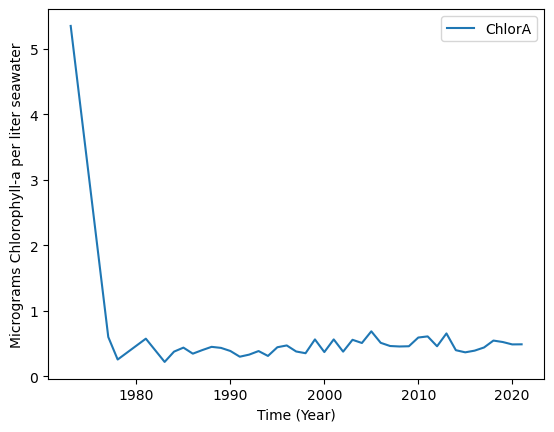

In [124]:
linegraph = bottledata.copy()

#ensuring data is measured by year
linegraph['Year'] = linegraph['Depth_ID'].astype(str)
linegraph['Year'] = linegraph['Year'].apply(lambda x: x[:2] + x[3:])
linegraph['Year'] = linegraph['Year'].str[:4]
linegraph['Year'] = pd.to_numeric(linegraph['Year'], errors = 'coerce')

#drop missing values at same time to avoid errors
linegraph = linegraph.dropna(subset=['Year', 'ChlorA'])

#group years with means
linegraph = linegraph.groupby('Year')['ChlorA'].mean().reset_index()

#make just ChlorA
linegraph = linegraph[['Year', 'ChlorA']]

#print histogram
%matplotlib inline
fig = plt.figure()

linegraph.plot(x='Year', y='ChlorA', kind='line')

plt.xlabel('Time (Year)')
plt.ylabel('Micrograms Chlorophyll-a per liter seawater')

linegraph.head()

# Task 4: Bubble chart 

,Depthm,T_degC,ChlorA
892906,3,12.716000,1.503000
892907,10,12.699000,1.524000
892908,19,12.620000,0.701000
892909,20,12.537000,0.694000
892910,30,12.320000,0.627000


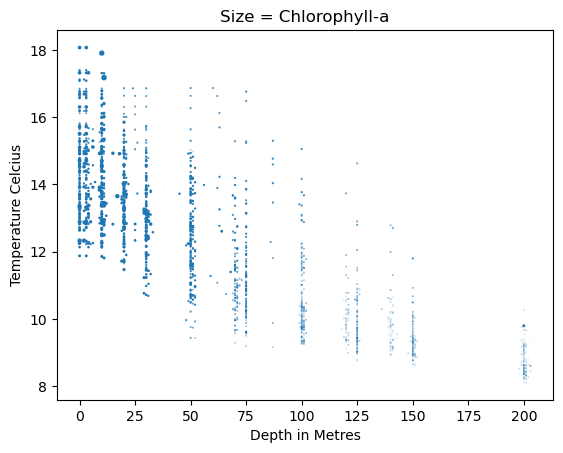

In [153]:
bubblechart = bottledata.copy()

#grab last 3 measurement sets and variables
bubblechart = bubblechart.tail(2465)
bubblechart = bubblechart[['Depthm', 'T_degC', 'ChlorA']]

#ensure numerical values
bubblechart['Depthm'] = pd.to_numeric(bubblechart['Depthm'], errors = 'coerce')
bubblechart['T_degC'] = pd.to_numeric(bubblechart['T_degC'], errors = 'coerce')
bubblechart['ChlorA'] = pd.to_numeric(bubblechart['ChlorA'], errors = 'coerce')

#drop empty values all at once
bubblechart = bubblechart.dropna(subset = ['Depthm', 'T_degC', 'ChlorA'])

#print plot
#x = temp - y = depth - size = chlorophyll-a
%matplotlib inline

fig = plt.figure()

plt.scatter(bubblechart['Depthm'], bubblechart['T_degC'], s = bubblechart['ChlorA']) 
plt.xlabel('Depth in Metres')
plt.ylabel('Temperature Celcius')
plt.title('Size = Chlorophyll-a')

bubblechart.head()

# Task 5: Select Plot

Depthm
0-10m        3.273802
11-50m       5.844941
51-100m     14.039521
101-200m+   28.900152
Name: SiO3uM, dtype: float64


C:\Users\jckkl\AppData\Local\Temp\ipykernel_3704\2531153992.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  piechart = piechart.groupby('Depthm')['SiO3uM'].mean()


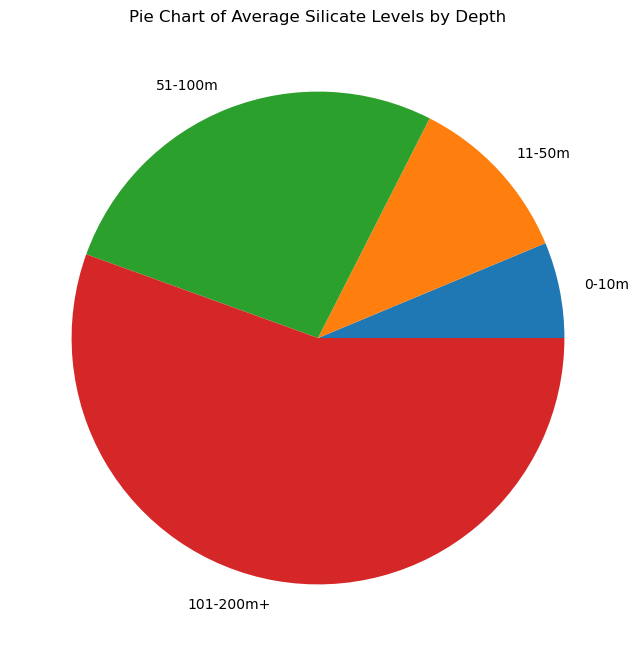

In [164]:
piechart = bottledata.copy()

#filtering
piechart = piechart.tail(2465)
piechart = piechart[['SiO3uM', 'Depthm']]
piechart['SiO3uM'] = pd.to_numeric(piechart['SiO3uM'], errors = 'coerce')
piechart['Depthm'] = pd.to_numeric(piechart['Depthm'], errors = 'coerce')

#average out depth
bi = [0, 10, 50, 100, 250]
la = ['0-10m', '11-50m', '51-100m', '101-200m+']
piechart['Depthm'] = pd.cut(piechart['Depthm'], bins = bi, labels = la, include_lowest = True)

#drop empty cells
piechart = piechart.dropna(subset = ['Depthm', 'SiO3uM'])

#average out the silicate levels by depth
piechart = piechart.groupby('Depthm')['SiO3uM'].mean()
print(piechart)

# Make the plot with pandas
piechart.plot(kind='pie', figsize=(8, 8))
plt.title("Pie Chart of Average Silicate Levels by Depth")
plt.ylabel("")
plt.show()